# 21 — Vertical Design / Grading 竖向设计

**Core question**: How does 竖向设计 (vertical design / grading) turn a raw
elevation surface into computable planning inputs — slope, earthwork
balance, and drainage organization?

**Answer**: three methods on a synthetic DEM (data-gated — no real DEM
asset in the repo, so 2D Gaussian-hill terrain stands in):

1. **M1 slope / aspect** — gradient magnitude and downhill azimuth from
   the numpy gradient, classified into the CJJ 83-2016 slope classes;
2. **M2 cut-fill balance** — 挖方/填方 volumes for a proposed building
   platform, plus the level that minimizes |cut - fill|;
3. **M3 D8 drainage** — flow direction → watershed basins → potential
   flooding risk areas.

All three methods are extracted into ``src/vertical.py`` and are plain
numpy, deterministic, CPU-only.  Target **B-05**.


## 0. Background — 竖向设计, grading, cut-fill, slope analysis

竖向设计 (vertical design) arranges the *third dimension* of a site: it
fixes platform elevations, grades the terrain, balances earthwork and
organizes drainage before any building goes down.  Three core
computations:

| # | 术语 | English | What it answers |
|---|---|---|---|
| 1 | 坡度 / 坡向 | slope / aspect | How steep is the land, and which way does it face? |
| 2 | 挖方 / 填方 | cut / fill | How much soil is removed / imported to reach a platform? |
| 3 | 汇水 / 分水 | drainage / watershed | Where does rain go, and where does it collect? |

Planning guidance — CJJ 83-2016《城市用地竖向规划规范》: slope classes for
场地适宜性.  Grading design targets 土方平衡 (balanced earthwork):
minimize |cut - fill| so no soil leaves or enters the site.

| slope % | class | suitability |
|---|---|---|
| < 5 | flat 平坦 | 建筑、道路无约束 |
| 5–15 | gentle 缓坡 | 台地式布置 |
| 15–25 | moderate 中坡 | 限制开发，护坡工程 |
| > 25 | steep 陡坡 | 禁建 / 高工程代价 |

**Data-gated**: real grading analysis needs a DEM (SRTM/ALOS 30 m,
机载 LiDAR or surveyed contours).  This notebook has no DEM asset, so it
generates deterministic synthetic terrain and runs exactly the algorithms
a real-DEM pipeline would run — swapping in a real raster is a one-line
change (``np.loadtxt`` / ``rasterio`` read).


## 1. Method 1 — Slope and aspect 坡度与坡向

The slope of a cell is the magnitude of the elevation gradient; the
aspect is the compass azimuth the surface slopes *toward* (downhill):

    slope   = sqrt(p^2 + q^2)          p = dz/dx (east),  q = dz/dy (north)
    aspect  = atan2(-p, -q)  in [0, 360) deg clockwise from north

Grid convention (same as ``src/vertical.py``): **row 0 = north**, col 0 =
west, cells are dx × dy m.  Slope is classified on the percent scale
(100 × tan of the angle).  Near-flat cells get aspect = -1 / "flat".


In [1]:
import sys
from pathlib import Path


def _repo_root():
    # Repo root = nearest ancestor containing both src/ and notebooks/.
    p = Path.cwd()
    while p != p.parent:
        if (p / "src").is_dir() and (p / "notebooks").is_dir():
            return p
        p = p.parent
    return Path.cwd()


ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm
from matplotlib.patches import Patch
from scipy import ndimage

# B-05 extraction: all three methods live in src/vertical.py
from src.vertical import (
    D8_DELTA,
    cut_fill_balance,
    flow_direction_d8,
    slope_aspect,
)

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False


DEM 60 x 60 cells at 10.0 m -> 0.6 x 0.6 km site
elevation: min 33.2 m, max 70.4 m, mean 45.1 m


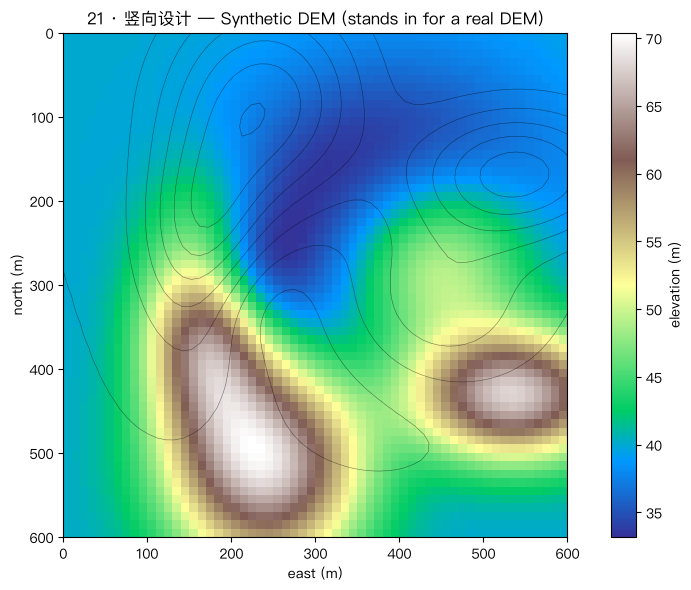

In [2]:
# ---- Synthetic DEM: 2D Gaussian hills -----------------------------------
# Real grading work starts from a DEM (SRTM/ALOS 30 m, 机载 LiDAR or
# surveyed contours).  This target is data-gated — no DEM asset yet — so
# build a deterministic stand-in: a smooth hills-and-valleys surface from
# 4 Gaussian humps + 2 troughs on a 40 m plateau (60 x 60 cells, 10 m
# spacing -> 600 x 600 m site).
def build_terrain(n=60, dx=10.0, dy=10.0, seed=42):
    rng = np.random.default_rng(seed)
    j, i = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    z = np.full((n, n), 40.0)
    for _ in range(4):                       # hills (positive amplitude)
        cx = rng.uniform(0.1, 0.9) * n
        cy = rng.uniform(0.1, 0.9) * n
        sx, sy = rng.uniform(0.08, 0.16), rng.uniform(0.08, 0.16)
        amp = rng.uniform(22.0, 38.0)
        z += amp * np.exp(-((i - cx) ** 2) / (2 * (sx * n) ** 2)
                          - ((j - cy) ** 2) / (2 * (sy * n) ** 2))
    for _ in range(2):                       # valleys (negative amplitude)
        cx = rng.uniform(0.2, 0.8) * n
        cy = rng.uniform(0.2, 0.8) * n
        sx, sy = rng.uniform(0.08, 0.22), rng.uniform(0.08, 0.22)
        amp = rng.uniform(-24.0, -14.0)
        z += amp * np.exp(-((i - cx) ** 2) / (2 * (sx * n) ** 2)
                          - ((j - cy) ** 2) / (2 * (sy * n) ** 2))
    return z, dx, dy


z, DX, DY = build_terrain()
ny, nx = z.shape
print(f"DEM {nx} x {ny} cells at {DX} m -> "
      f"{nx * DX / 1000:.1f} x {ny * DY / 1000:.1f} km site")
print(f"elevation: min {z.min():.1f} m, max {z.max():.1f} m, "
      f"mean {z.mean():.1f} m")

# ---- figure: the synthetic terrain ---------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(z, origin="upper", extent=[0, nx * DX, ny * DY, 0],
               cmap="terrain")
ax.contour(z, levels=8, colors="k", linewidths=0.4, alpha=0.5,
           extent=[0, nx * DX, ny * DY, 0])
ax.set_title("21 · 竖向设计 — Synthetic DEM (stands in for a real DEM)")
ax.set_xlabel("east (m)")
ax.set_ylabel("north (m)")
fig.colorbar(im, ax=ax, label="elevation (m)")
fig.tight_layout()
fig.savefig(OUTPUTS / "21-terrain.png", dpi=200, bbox_inches="tight")
plt.show()


          flat <5%:  38.2% of site
      gentle 5-15%:  34.1% of site
   moderate 15-25%:  20.3% of site
        steep >25%:   7.4% of site
aspect sectors: 0: 9.6%, 1: 14.8%, 2: 9.2%, 3: 11.8%, 4: 12.0%, 5: 8.4%, 6: 20.8%, 7: 13.6%


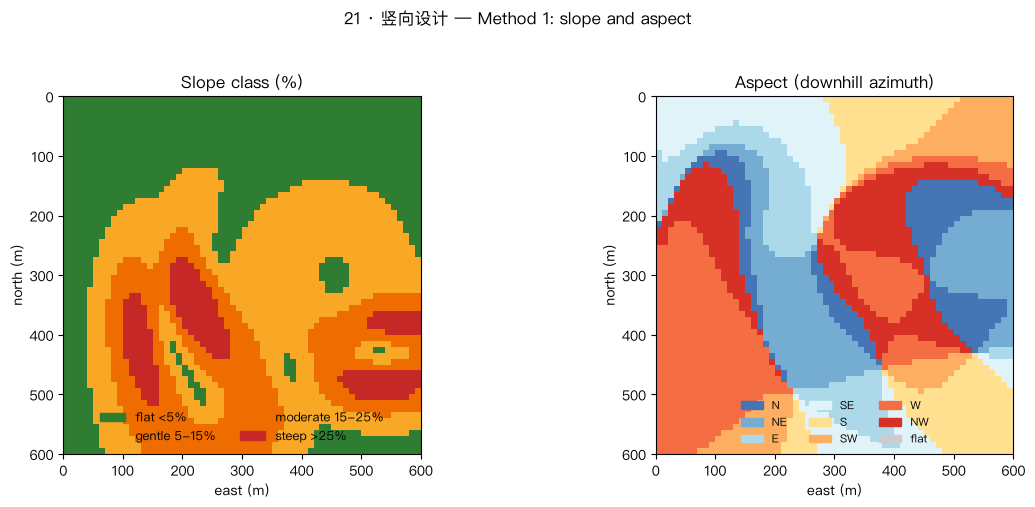

In [3]:
# ---- Method 1: slope + aspect --------------------------------------------
sl = slope_aspect(z, dx=DX, dy=DY)

# Planning slope classes (CJJ 83-2016): <5% flat, 5-15% gentle,
# 15-25% moderate, >25% steep
THRESHOLDS = [5.0, 15.0, 25.0]
CLASS_NAMES = ["flat <5%", "gentle 5-15%", "moderate 15-25%", "steep >25%"]
slope_class = np.digitize(sl["slope_pct"], THRESHOLDS)
counts = np.bincount(slope_class.ravel(), minlength=4)
for name, c in zip(CLASS_NAMES, counts):
    print(f"{name:>18}: {100 * c / slope_class.size:5.1f}% of site")

# aspect: 8 cardinal sectors (flat -> 8, drawn grey)
sector = np.where(sl["aspect_dir"] == "flat", 8,
                  ((sl["aspect_deg"] + 22.5) % 360) // 45).astype(int)
names, cnts = np.unique(sector, return_counts=True)
print("aspect sectors:",
      ", ".join(f"{int(n)}: {100 * c / sector.size:.1f}%"
                for n, c in zip(names, cnts)))

# ---- figure: slope classes + aspect compass ------------------------------
ASPECT_NAMES = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "flat"]
ASPECT_COLORS = ["#4575b4", "#74add1", "#abd9e9", "#e0f3f8",
                 "#fee090", "#fdae61", "#f46d43", "#d73027", "#cccccc"]
SLOPE_COLORS = ["#2e7d32", "#f9a825", "#ef6c00", "#c62828"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.4))
slope_cmap = ListedColormap(SLOPE_COLORS)
im1 = ax1.imshow(slope_class, origin="upper",
                 norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4),
                 extent=[0, nx * DX, ny * DY, 0], cmap=slope_cmap)
ax1.set_title("Slope class (%)")
ax1.legend(handles=[Patch(color=c, label=n) for c, n in
                    zip(SLOPE_COLORS, CLASS_NAMES)],
           loc="lower center", ncol=2, frameon=False, fontsize=9)
im2 = ax2.imshow(sector, origin="upper", vmin=0, vmax=8,
                 extent=[0, nx * DX, ny * DY, 0],
                 cmap=ListedColormap(ASPECT_COLORS))
ax2.set_title("Aspect (downhill azimuth)")
ax2.legend(handles=[Patch(color=c, label=n) for c, n in
                    zip(ASPECT_COLORS, ASPECT_NAMES)],
           loc="lower center", ncol=3, frameon=False, fontsize=8)
for ax in (ax1, ax2):
    ax.set_xlabel("east (m)")
    ax.set_ylabel("north (m)")
fig.suptitle("21 · 竖向设计 — Method 1: slope and aspect", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(OUTPUTS / "21-slope-aspect.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Method 2 — Cut-fill balance 挖填方平衡

场地平整 (site grading) brings a parcel to a horizontal platform at
elevation E.  Cells above E need 挖方 (cut — soil removed), cells below
need 填方 (fill — soil imported):

    cut  = sum(max(z - E, 0)) * dx * dy
    fill = sum(max(E - z, 0)) * dx * dy

Because ``cut - fill = sum(z - E)`` over the graded cells, the level with
|cut - fill| = 0 is exactly the **area-weighted mean elevation** — the
textbook 土方平衡 level.  We test a proposed platform (mean + 2 m, an
above-grade building pad), then sweep all candidate levels and let
``cut_fill_balance()`` find the balanced one.


proposed platform 47.1 m: cut 1066 k m3, fill 1786 k m3, net -720 k m3 (soil to import)
balanced platform 45.12 m: cut = fill = 1316 k m3, balance 0.000 k m3


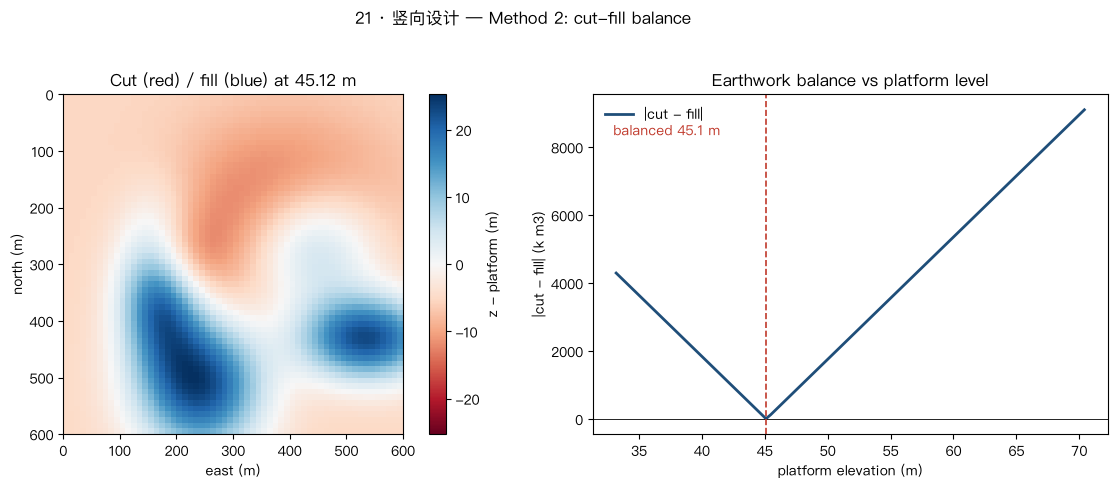

In [4]:
# ---- Method 2: cut-fill balance for a building platform ------------------
# 场地平整: bring the parcel to a horizontal platform at elevation E.
# Proposal: mean + 2 m (a slightly above-grade building platform).
proposed = float(z.mean()) + 2.0
r = cut_fill_balance(z, platform_elev=proposed, dx=DX, dy=DY)
print(f"proposed platform {proposed:.1f} m: "
      f"cut {r['cut'] / 1e3:.0f} k m3, fill {r['fill'] / 1e3:.0f} k m3, "
      f"net {r['net'] / 1e3:+.0f} k m3 (soil to import)")

# balanced level: |cut - fill| minimal — exactly the area-weighted mean
opt = cut_fill_balance(z, dx=DX, dy=DY)
print(f"balanced platform {opt['platform_elev']:.2f} m: "
      f"cut = fill = {opt['cut'] / 1e3:.0f} k m3, "
      f"balance {opt['balance'] / 1e3:.3f} k m3")

# sweep all candidate levels to see the balance curve
levels = np.linspace(z.min(), z.max(), 101)
curve = np.array([cut_fill_balance(z, platform_elev=e, dx=DX, dy=DY)["balance"]
                  for e in levels])

# ---- figure: cut/fill map + balance curve --------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2))
dz = z - opt["platform_elev"]
vmax = np.abs(dz).max()
im = ax1.imshow(dz, origin="upper", cmap="RdBu", vmin=-vmax, vmax=vmax,
                extent=[0, nx * DX, ny * DY, 0])
ax1.set_title(f"Cut (red) / fill (blue) at {opt['platform_elev']:.2f} m")
ax1.set_xlabel("east (m)")
ax1.set_ylabel("north (m)")
fig.colorbar(im, ax=ax1, label="z - platform (m)")
ax2.plot(levels, curve / 1e3, color="#1f4e79", lw=2, label="|cut - fill|")
ax2.axhline(0.0, color="k", lw=0.6)
ax2.axvline(opt["platform_elev"], color="#c0392b", ls="--", lw=1.2)
ax2.annotate(f"balanced {opt['platform_elev']:.1f} m",
             xy=(opt["platform_elev"], 0), xytext=(0.04, 0.88),
             textcoords="axes fraction", color="#c0392b", fontsize=10)
ax2.set_xlabel("platform elevation (m)")
ax2.set_ylabel("|cut - fill| (k m3)")
ax2.set_title("Earthwork balance vs platform level")
ax2.legend(loc="upper left", frameon=False)
fig.suptitle("21 · 竖向设计 — Method 2: cut-fill balance", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(OUTPUTS / "21-cut-fill.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Method 3 — Drainage direction and watershed 汇水分析

D8 (O'Callaghan & Mark 1984) assigns each cell the direction of its
steepest *drop / distance* neighbour; a cell with no strictly lower
neighbour is a **sink** (no outflow).  ESRI direction codes:

| 32 | 64 | 128 |
|---|---|---|
| 16 | 0  | 1   |
| 8  | 4  | 2   |

(N = 64, E = 1, S = 4, W = 16; diagonal codes are their combinations).
Following the D8 chain from every cell to its sink partitions the site
into **watersheds** (basins); **flow accumulation** counts how many
cells' runoff passes through each cell.  Sinks plus high-accumulation
valley cells = potential flooding risk areas (内涝风险).


sinks (no strictly-lower neighbour): 4 / 3600 cells
scipy 3x3-minimum pits: 4 — identical on this flat-free smooth DEM: True


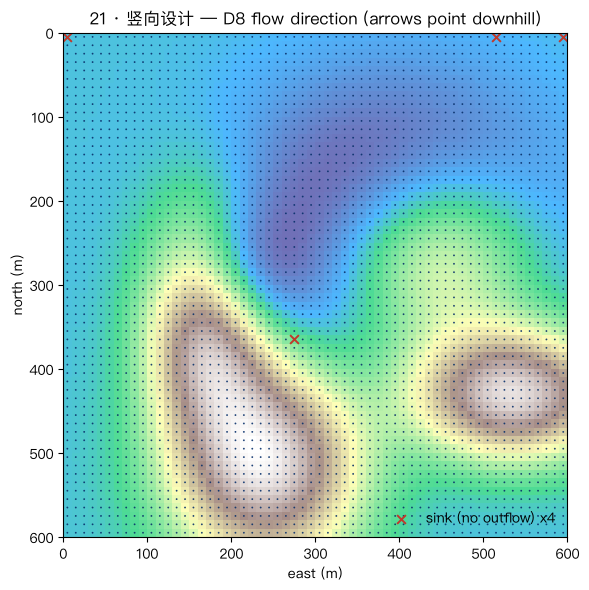

In [5]:
# ---- Method 3: drainage direction (D8) -----------------------------------
codes, sinks = flow_direction_d8(z)
n_sinks = int(sinks.sum())
print(f"sinks (no strictly-lower neighbour): {n_sinks} / {z.size} cells")

# cross-check with scipy: pits = cells equal to their 3x3 minimum
pits = z == ndimage.minimum_filter(z, size=3)
print(f"scipy 3x3-minimum pits: {pits.sum()} — identical on this "
      f"flat-free smooth DEM: {np.array_equal(pits, sinks)}")

# ---- figure: flow direction arrows + sink markers ------------------------
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(z, origin="upper", extent=[0, nx * DX, ny * DY, 0],
          cmap="terrain", alpha=0.7)
js, is_ = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
di_arr = np.zeros((ny, nx))
dj_arr = np.zeros((ny, nx))
for code, (dj, di) in D8_DELTA.items():
    m = codes == code
    di_arr[m], dj_arr[m] = di, dj
flow = np.ma.masked_where(codes == 0, di_arr)   # no arrow on sinks
ax.quiver(is_ * DX + DX / 2, (ny - js) * DY - DY / 2, flow, dj_arr,
          angles="xy", scale_units="xy", scale=DX, width=0.004,
          color="#08306b", alpha=0.9)
sy, sx = np.nonzero(sinks)
ax.scatter(sx * DX + DX / 2, (ny - sy) * DY - DY / 2, marker="x",
           color="#c0392b", s=40, lw=1.4, label=f"sink (no outflow) x{n_sinks}")
ax.legend(loc="lower right", frameon=False)
ax.set_title("21 · 竖向设计 — D8 flow direction (arrows point downhill)")
ax.set_xlabel("east (m)")
ax.set_ylabel("north (m)")
fig.tight_layout()
fig.savefig(OUTPUTS / "21-flow-direction.png", dpi=200, bbox_inches="tight")
plt.show()


watersheds: 4 (one per sink)
largest basin 1: 2845 cells = 79.0% of site
basin sizes: 2845, 471, 227, 57


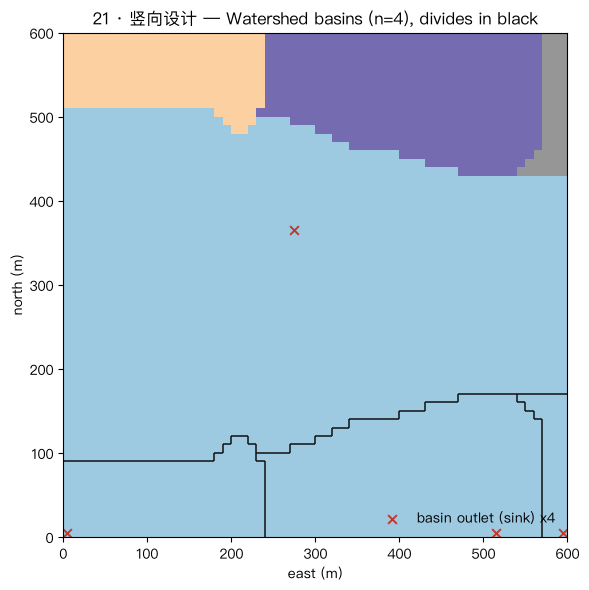

In [6]:
# ---- Watersheds: every cell drains to exactly one sink -------------------
def basin_labels(codes, sinks):
    """Basin id per cell = the id of the sink its D8 chain ends at.

    Chain tracing with memoisation: a chain that reaches an already
    labelled cell inherits that label (path compression in effect).
    """
    ny, nx = codes.shape
    labels = np.zeros((ny, nx), dtype=int)
    sink_id = np.zeros((ny, nx), dtype=int)
    sink_id[sinks] = np.arange(1, int(sinks.sum()) + 1)
    for j in range(ny):
        for i in range(nx):
            if labels[j, i]:
                continue
            chain = []
            jj, ii = j, i
            while not labels[jj, ii]:
                chain.append((jj, ii))
                if sinks[jj, ii]:
                    lab = int(sink_id[jj, ii])
                    break
                dj, di = D8_DELTA[codes[jj, ii]]
                jj, ii = jj + dj, ii + di
            else:
                lab = int(labels[jj, ii])
            for c in chain:
                labels[c] = lab
    return labels


def watershed_boundaries(labels):
    """Pixel-edge segments separating cells of different basins."""
    segs = []
    ny, nx = labels.shape
    for j in range(ny):
        for i in range(nx):
            if i + 1 < nx and labels[j, i] != labels[j, i + 1]:
                segs.append(((i + 1, j), (i + 1, j + 1)))
            if j + 1 < ny and labels[j, i] != labels[j + 1, i]:
                segs.append(((i, j + 1), (i + 1, j + 1)))
    return segs


basins = basin_labels(codes, sinks)
ids, sizes = np.unique(basins, return_counts=True)
largest = ids[int(np.argmax(sizes))]
print(f"watersheds: {len(ids)} (one per sink)")
print(f"largest basin {largest}: {sizes.max()} cells "
      f"= {100 * sizes.max() / basins.size:.1f}% of site")
print("basin sizes:", ", ".join(str(int(s)) for s in np.sort(sizes)[::-1]))

# ---- figure: basins + watershed divides ----------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(basins, origin="upper", vmin=0.5, vmax=ids.max() + 0.5,
               extent=[0, nx * DX, ny * DY, 0], cmap="tab20c",
               interpolation="nearest")
divides = watershed_boundaries(basins)
seg_m = [((x0 * DX, (ny - y0) * DY), (x1 * DX, (ny - y1) * DY))
         for (x0, y0), (x1, y1) in divides]
ax.add_collection(LineCollection(seg_m, colors="#111111", linewidths=1.1))
ax.scatter(sx * DX + DX / 2, (ny - sy) * DY - DY / 2, marker="x",
           color="#c0392b", s=40, lw=1.4,
           label=f"basin outlet (sink) x{n_sinks}")
ax.legend(loc="lower right", frameon=False)
ax.set_title(f"21 · 竖向设计 — Watershed basins (n={len(ids)}), "
             "divides in black")
ax.set_xlabel("east (m)")
ax.set_ylabel("north (m)")
ax.set_xlim(0, nx * DX)
ax.set_ylim(0, ny * DY)
fig.tight_layout()
fig.savefig(OUTPUTS / "21-watersheds.png", dpi=200, bbox_inches="tight")
plt.show()


max flow accumulation: 2845 cells = 79.0% of site (the largest basin)
isolated ponding zones: 4
potential flooding risk cells: 363 = 10.1% of site


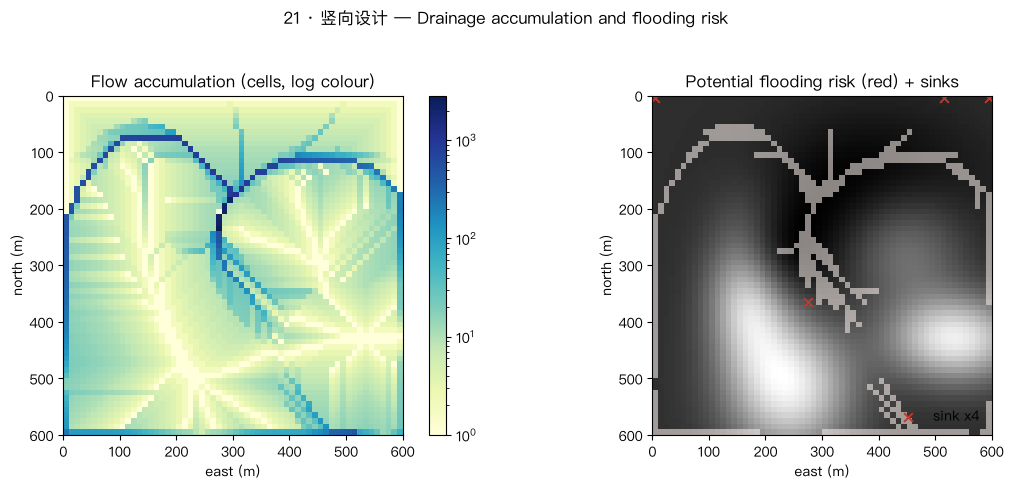

In [7]:
# ---- Flow accumulation + potential flooding risk -------------------------
def flow_accumulation(dem, codes, sinks):
    """How many cells' runoff passes through each cell (source = 1).

    Process cells in descending elevation: when a cell is handled, every
    strictly higher cell has already added its weight downstream, so the
    count is final.  Equal-elevation neighbours never drain to each other
    (D8 makes them sinks), so there are no cycles.
    """
    acc = np.ones(dem.shape, dtype=int)
    order = np.unravel_index(np.argsort(-dem, axis=None), dem.shape)
    for j, i in zip(order[0], order[1]):
        if sinks[j, i]:
            continue
        dj, di = D8_DELTA[codes[j, i]]
        acc[j + dj, i + di] += acc[j, i]
    return acc


acc = flow_accumulation(z, codes, sinks)
print(f"max flow accumulation: {acc.max()} cells "
      f"= {100 * acc.max() / z.size:.1f}% of site (the largest basin)")

# ponding zones: sink cells that can never drain (isolated components)
pond = ndimage.label(sinks, structure=np.ones((3, 3)))[0]
print(f"isolated ponding zones: {pond.max()}")

# flooding risk: sinks + cells concentrating runoff (top-10% accumulation)
risk = sinks | (acc >= np.percentile(acc, 90))
print(f"potential flooding risk cells: {risk.sum()} "
      f"= {100 * risk.sum() / z.size:.1f}% of site")

# ---- figure: accumulation + risk map -------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2))
im1 = ax1.imshow(acc, origin="upper", norm=LogNorm(vmin=1, vmax=acc.max()),
                 cmap="YlGnBu", extent=[0, nx * DX, ny * DY, 0])
ax1.set_title("Flow accumulation (cells, log colour)")
fig.colorbar(im1, ax=ax1)
ax2.imshow(z, origin="upper", extent=[0, nx * DX, ny * DY, 0], cmap="gray")
ax2.imshow(np.ma.masked_where(~risk, np.ones_like(z)), origin="upper",
           cmap="Reds", alpha=0.55, extent=[0, nx * DX, ny * DY, 0])
ax2.scatter(sx * DX + DX / 2, (ny - sy) * DY - DY / 2, marker="x",
            color="#c0392b", s=40, lw=1.4, label=f"sink x{n_sinks}")
ax2.legend(loc="lower right", frameon=False)
ax2.set_title("Potential flooding risk (red) + sinks")
for ax in (ax1, ax2):
    ax.set_xlabel("east (m)")
    ax.set_ylabel("north (m)")
fig.suptitle("21 · 竖向设计 — Drainage accumulation and flooding risk",
             fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0.06, 1, 0.96])
fig.savefig(OUTPUTS / "21-flood-risk.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Comparison and Conclusions 三方法对比

| Method | Input | Output | Planning use |
|---|---|---|---|
| M1 slope/aspect | DEM | slope %, deg, aspect 8-dir, 4 slope classes | 用地适宜性分级、场地平整方向、日照坡向 |
| M2 cut/fill | DEM + platform level | cut/fill m³, balanced level | 土方平衡、土石方量估算 |
| M3 D8 drainage | DEM | flow dir, sinks, watersheds, accumulation, risk map | 排水组织、汇水分区、内涝风险识别 |

Key findings on the synthetic site (600 × 600 m, 33.2–70.4 m relief):

- **M1**: 38.2 % of the site is flat (< 5 %), 34.1 % gentle, 20.3 %
  moderate, 7.4 % steep — the steep flanks of the two hill clusters read
  clearly and would drive 护坡工程 / building placement.
- **M2**: the balanced platform sits at 45.1 m (the area-weighted mean),
  cut = fill ≈ 1316 k m³.  Raising the platform to 47.1 m (mean + 2 m)
  imports ≈ 720 k m³ of fill — a measurable grading cost, as expected
  from a valley-dominated site.
- **M3**: 4 sinks → 4 watersheds; the largest basin drains 79 % of the
  site and its outlet shows the peak flow accumulation (2845 cells).
  ~10 % of cells are flagged as potential flooding risk (sinks + top-10 %
  accumulation), i.e. the two valley floors.

Caveats and next steps:

- **D8 flats**: cells without a strictly lower neighbour become sinks,
  so flat terraces fragment the drainage.  Real tools add flat-resolution
  (Garbrecht & Martz); the synthetic DEM is flat-free by construction.
- **Boundary**: cells can only drain inside the grid — the outer edge can
  create artificial pits; real work uses a buffered domain.
- **Data-gated**: swap the Gaussian terrain for a real DEM (SRTM/ALOS
  30 m or LiDAR); all three functions take a plain elevation array.
- Next: terrace design (台地) with per-terrace cut-fill, storm routing
  (单位线 hydrographs), and a WhiteboxTools/gdal_fillnodata comparison.


In [8]:
# ---- Module verification (src/vertical.py) -------------------------------
# The notebook runs on the extracted module; independently re-verify the
# three public functions.
p = np.gradient(z, DX, axis=1)
q = -np.gradient(z, DY, axis=0)
assert np.allclose(sl["slope_pct"], 100.0 * np.hypot(p, q))   # M1 gradient

e = 47.0
r1 = cut_fill_balance(z, platform_elev=e, dx=DX, dy=DY)
assert np.isclose(r1["net"], (z - e).sum() * DX * DY)         # M2 linearity

jj, ii, steps = 3, 5, 0                                       # M3 acyclic
while not sinks[jj, ii]:
    dj, di = D8_DELTA[codes[jj, ii]]
    assert z[jj, ii] > z[jj + dj, ii + di]
    jj, ii, steps = jj + dj, ii + di, steps + 1
    assert steps < z.size
print("module verification OK: gradient slope, cut-fill linearity, "
      "D8 acyclic")


module verification OK: gradient slope, cut-fill linearity, D8 acyclic
